In [1]:
# Базовые библиотеки для анализа данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение выборки
from sklearn.model_selection import train_test_split

# Модели ансамблей (тема лабы!)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Метрики качества
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    roc_curve, 
    classification_report, 
    confusion_matrix
)

# Настройки графиков для красивого отображения
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

In [3]:
# 1. Загружаем именно ИЗНАЧАЛЬНЫЙ, сырой датасет
df_raw = pd.read_csv('stroke_data.csv')

print(f"Размер изначального датасета: {df_raw.shape}")
print(f"Количество пропусков в сырых данных:\n{df_raw.isna().sum()[df_raw.isna().sum() > 0]}")
display(df_raw.head(3))

# Делаем копию для подготовки
df = df_raw.copy()

# 2. Удаляем идентификатор (id), так как он не является признаком болезни
df = df.drop(columns=['id'])

# 3. В признаке gender есть одна строка со значением 'Other' — убираем её
df = df[df['gender'] != 'Other']

# 4. Заполняем пропуски в bmi медианным значением (чтобы sklearn не выдавал ошибку)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# 5. Кодируем текстовые категории в числа (0 и 1)
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 6. Отделяем признаки (X) от целевой переменной (y)
X = df.drop(columns=['stroke'])
y = df['stroke']

print("\nДанные успешно подготовлены для ансамблей!")
print(f"Размер матрицы признаков X: {X.shape}")
print(f"Распределение целевого класса (0 - здоров, 1 - инсульт):\n{y.value_counts()}")

Размер изначального датасета: (5110, 12)
Количество пропусков в сырых данных:
bmi    201
dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1



Данные успешно подготовлены для ансамблей!
Размер матрицы признаков X: (5109, 15)
Распределение целевого класса (0 - здоров, 1 - инсульт):
stroke
0    4860
1     249
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка:  {X_test.shape[0]} строк")

Обучающая выборка: 4087 строк
Тестовая выборка:  1022 строк


In [5]:
# Инициализация модели Случайного леса
rf_model = RandomForestClassifier(
    n_estimators=150,       # количество деревьев
    max_features='sqrt',    # корень из числа признаков (по теории методички)
    oob_score=True,         # ВКЛЮЧАЕМ OOB-оценку!
    random_state=42,
    n_jobs=-1               # распараллеливание на все ядра процессора
)

# Обучение модели
rf_model.fit(X_train, y_train)

# Получаем вероятности и классы на тесте
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Оценка OOB
print("=" * 45)
print("РЕЗУЛЬТАТЫ СЛУЧАЙНОГО ЛЕСА:")
print(f"OOB Accuracy: {rf_model.oob_score_:.4f}")
print(f"OOB Error:    {1 - rf_model.oob_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, rf_probs):.4f}")
print("=" * 45)

РЕЗУЛЬТАТЫ СЛУЧАЙНОГО ЛЕСА:
OOB Accuracy: 0.9498
OOB Error:    0.0502
Test Accuracy: 0.9501
Test ROC-AUC:  0.7937


In [6]:
# 1. AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)
ada_model.fit(X_train, y_train)

ada_preds = ada_model.predict(X_test)
ada_probs = ada_model.predict_proba(X_test)[:, 1]

# 2. Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3,      # небольшая глубина деревьев, чтобы избежать переобучения
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:, 1]

print("Модели бустинга успешно обучены!")

Модели бустинга успешно обучены!


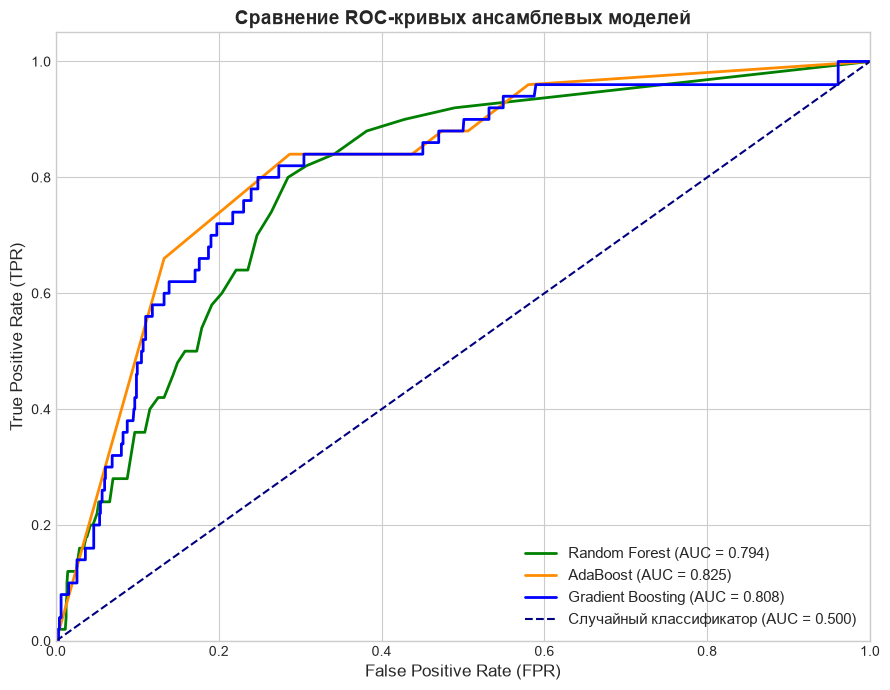

,Модель,Test Accuracy,Test ROC-AUC
0,Random Forest,0.950098,0.793735
1,AdaBoost,0.951076,0.825134
2,Gradient Boosting,0.948141,0.808436


In [7]:
# Расчет точек ROC-кривой для каждой модели
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_probs)
auc_ada = roc_auc_score(y_test, ada_probs)

fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
auc_gb = roc_auc_score(y_test, gb_probs)

# Построение графика
plt.figure(figsize=(9, 7))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green', lw=2)
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.3f})', color='darkorange', lw=2)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})', color='blue', lw=2)

# Линия случайного угадывания (диагональ)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1.5, label='Случайный классификатор (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Сравнение ROC-кривых ансамблевых моделей', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

# Итоговая сводка в виде красивой таблицы
results_table = pd.DataFrame({
    'Модель': ['Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Test Accuracy': [accuracy_score(y_test, rf_preds), accuracy_score(y_test, ada_preds), accuracy_score(y_test, gb_preds)],
    'Test ROC-AUC': [auc_rf, auc_ada, auc_gb]
})

display(results_table)

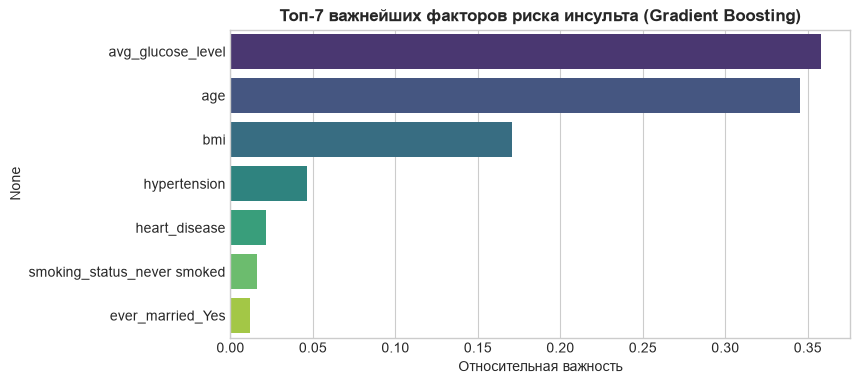

In [9]:
# Посмотрим важность признаков на основе лучшей модели (Gradient Boosting)
feature_importances = pd.Series(gb_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(7)

plt.figure(figsize=(8, 4))
# Добавили hue=top_features.index и legend=False по новым правилам Seaborn:
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
plt.title('Топ-7 важнейших факторов риска инсульта (Gradient Boosting)', fontsize=12, fontweight='bold')
plt.xlabel('Относительная важность')
plt.show()